In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import pandas as pd
plt.style.use('seaborn-colorblind')

<ipython-input-1-a35ce1de31fc>:6: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-colorblind')


#SPC
- primary tool to improve *process* performance & reduce variability in the *process*

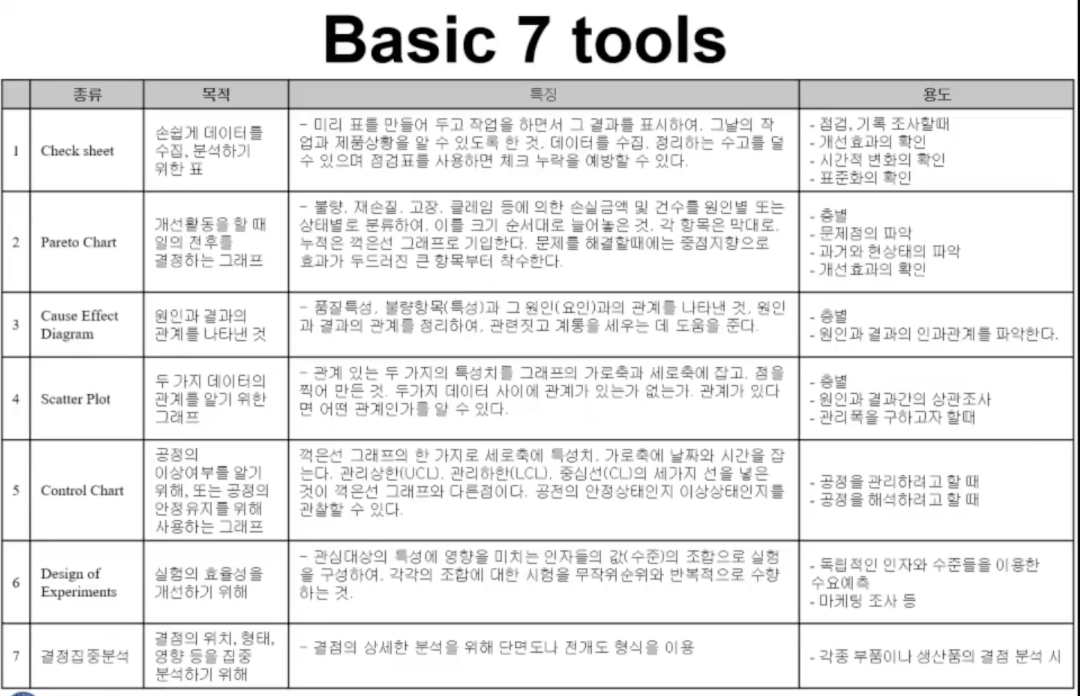

## Pareto Chart

- 원인이 되는 인자들을 중요도 순으로 나열
- Frequency가 큰 순서대로 histogram에 그려줌
- 백분율 하면 퍼센티지 정보도 확인 가능함

In [ ]:
def Pareto(problems, values):
    df = pd.DataFrame({'Values': values})
    df.index = problems
    df = df.sort_values(by='Values',ascending=False)
    df["cumpercentage"] = df["Values"].cumsum()/df["Values"].sum()*100 #누적합 퍼센트

    #그래프
    plt.figure(figsize=(14,6)) # 그래프 사이즈 설정
    plt.bar(df.index, df["Values"], color="C0") # bar 그래프 생성
    plt.xticks(rotation=70) # x축 설정
    ax = plt.twinx() #x축 공유
    ax.plot(df.index, df["cumpercentage"], color="r", marker="D") #line graph 생성
    ax.yaxis.set_major_formatter(PercentFormatter())
    plt.title("Pareto Diagram")
    plt.tick_params(axis="y", colors="k")
    plt.tick_params(axis="y", colors="r")
    plt.grid()
    plt.show()

In [ ]:
problems=['overpriced','small_portions','wait time','food is tasteless','no atmosphere','not clean','too noisy','food too salty','unfriendly staff','food not fresh']
values=[789,9,109,65,45,30, 78, 240, 362, 105]

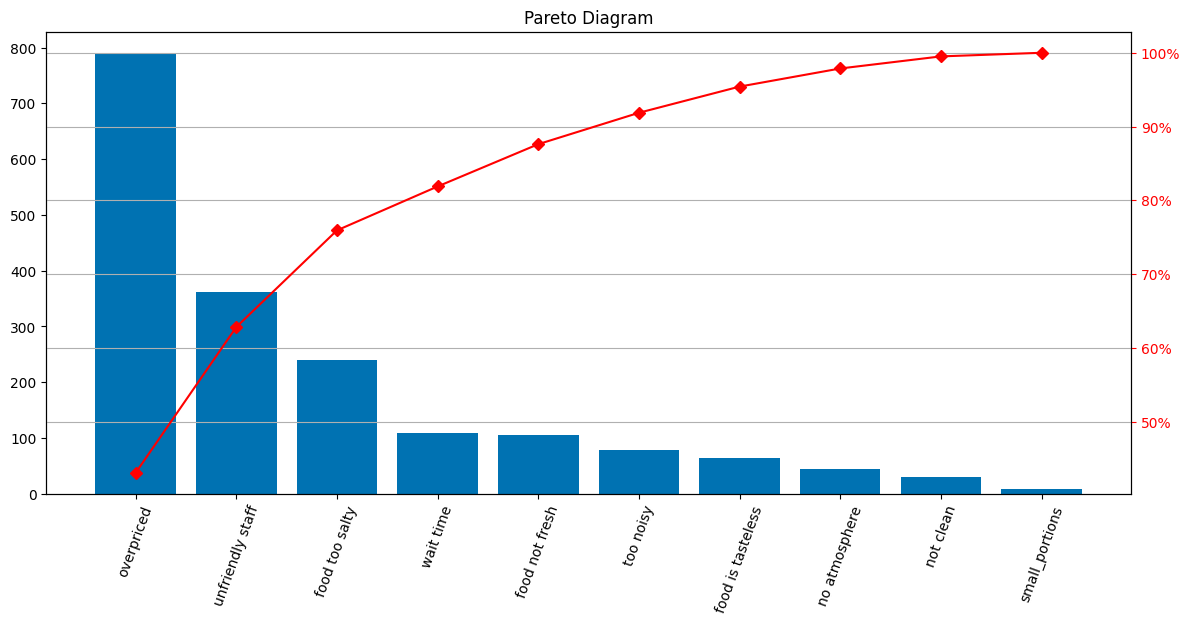

In [ ]:
Pareto(problems,values)

- 두가지 문제 (overpriced, unfriendly staff) 를 해결하면 전체 문제의 거의 65% 를 해결함

## Scatter Plot

- 두 연속형 변수간의 상관관계 파악

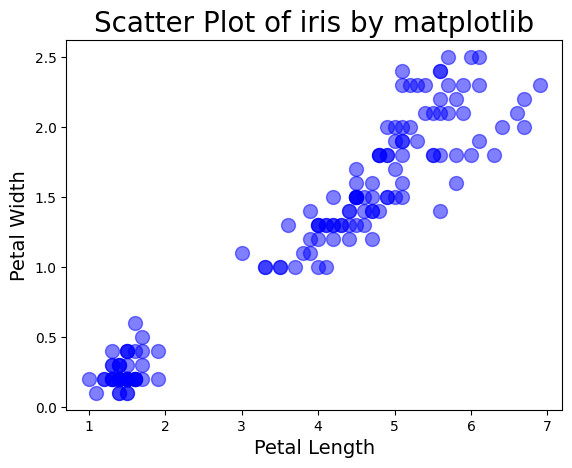

In [ ]:
# Basic Scatter Plot
iris = sns.load_dataset('iris')

plt.plot('petal_length',  # x
         'petal_width',  # y
         data=iris,
         linestyle='none', marker='o', markersize=10,color='blue', alpha=0.5)

plt.title('Scatter Plot of iris by matplotlib', fontsize=20)
plt.xlabel('Petal Length', fontsize=14)
plt.ylabel('Petal Width', fontsize=14)
plt.show()


## Control Chart (관리도)

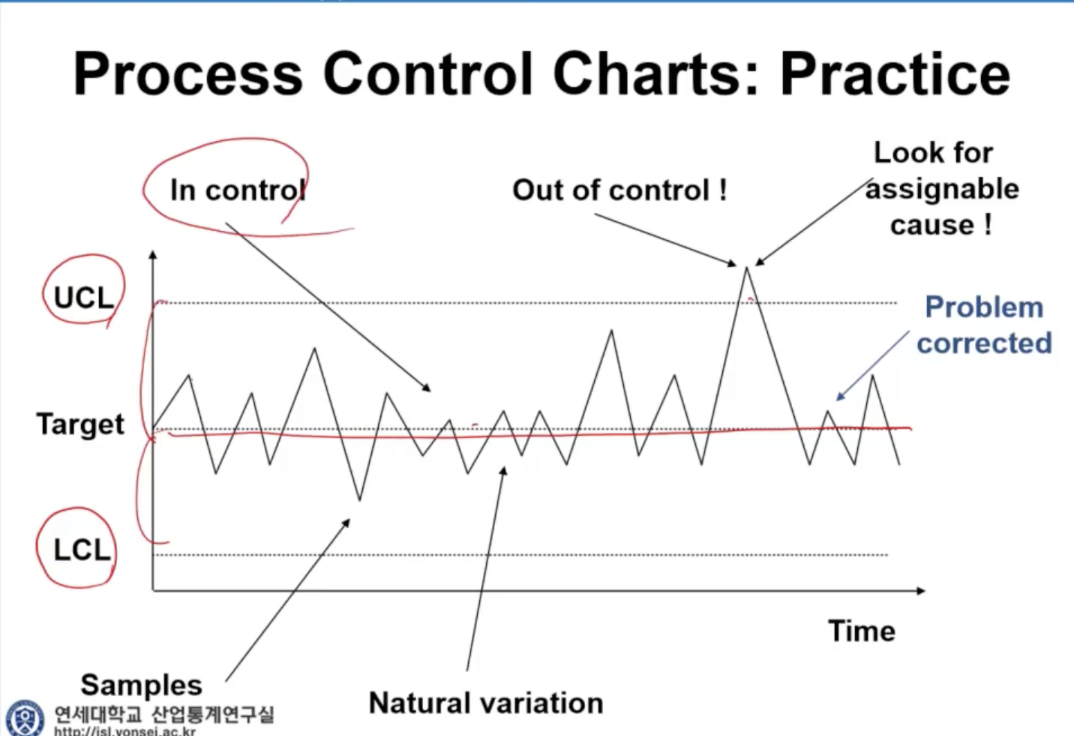

Design of control chart -> reliability
- [sample size](https://fastercapital.com/content/Sample-Size--The-Power-of-Numbers--How-Sample-Size-Affects-Control-Chart-Reliability.html)
  - A sample size that is too small may lead to results that are not representative of the population, while a sample size that is too large may be unnecessarily costly or time-consuming. The key is to find a balance that provides a high level of confidence in the results without being wasteful of resources.
  - Assumptions: normally distributed, data independence
- [frequency of sampling](https://www.uyemura.com/articles/statistical-process-control-charts.html)
  - According to the U. S. DoD Handbook Companion Document to Mil-Std-1916, the following factors should be considered when determining sampling frequency:
  1) **Process change Rapidity**. The smaller the interval between inherent process changes, the smaller the interval between subgroups. 2) **Relative variability of the process**. If the process variability is minimal and the chance of producing an out-of-specification product is negligible, then such a process may be monitored infrequently. This is beneficial when the cost of sampling and testing is high. 3) **Initial data collection**. At first, it may be desirable to sample frequently to arrive at conclusions quickly. After sufficient process knowledge is gained, reducing the frequency of sampling may be advisable. 4) **Potential non-conforming product**. How much product a supplier can produce between the beginning of a change in process average and the detection of that change should influence the sampling interval. This relates to factors such as production rates and inspection and rework costs.
- control limit
  - Control limits are calculated based on historical data and are typically set at three standard deviations from the process mean. These limits define the boundaries of common cause variation. A point outside these limits suggests a special cause that may require investigation.


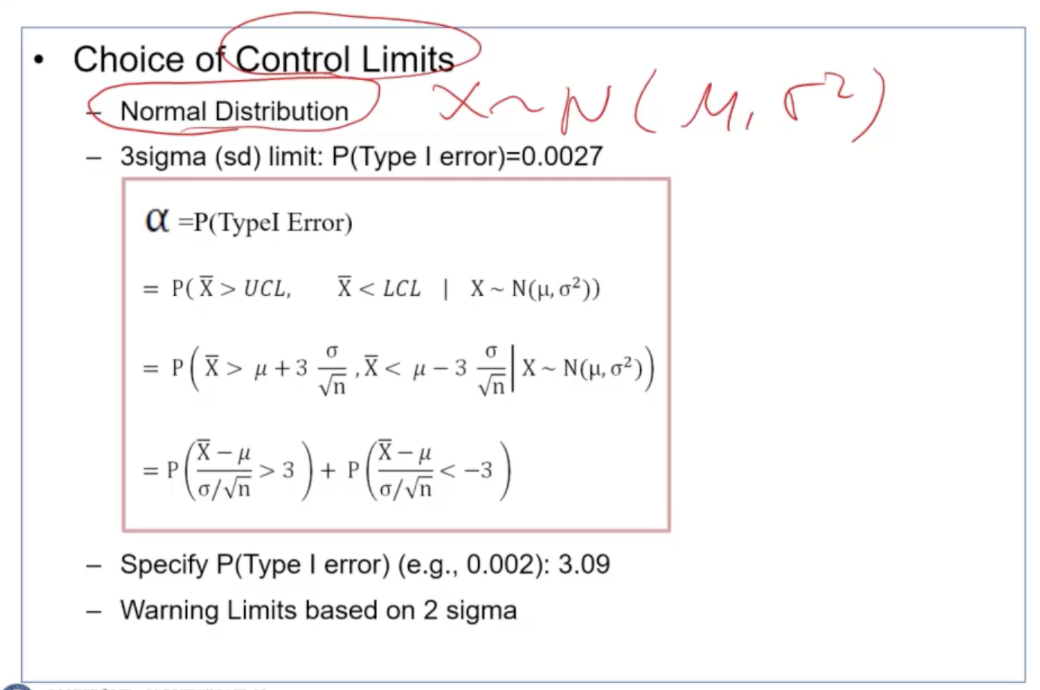

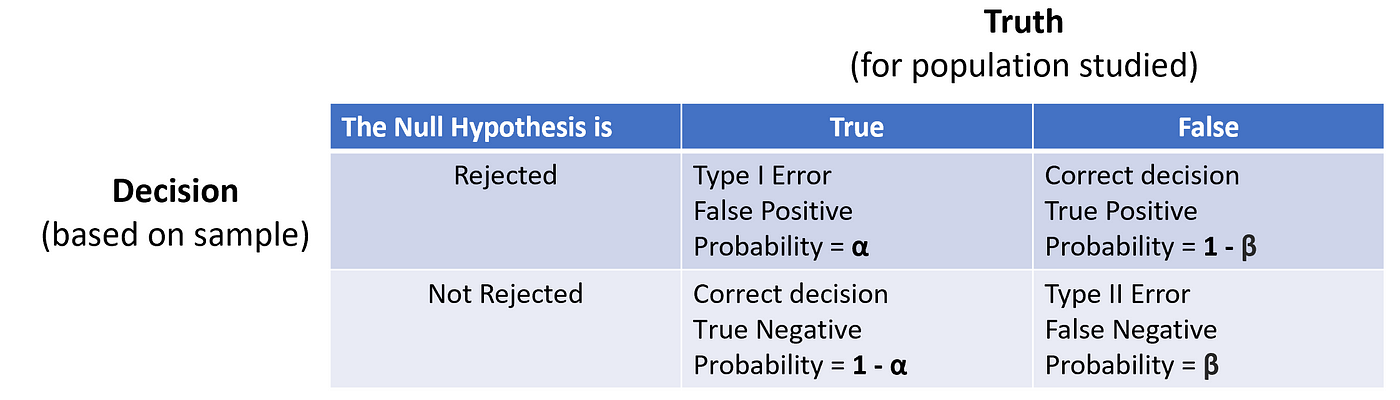

- Type I Error (False Positive): Occurs when a control chart **incorrectly signals an out-of-control process when it is actually in control**. For example, if a control chart signals a need for process adjustment when none is needed, it can lead to unnecessary changes and increased costs.

- Type II Error (False Negative): Happens when a control chart **fails to detect an actual out-of-control condition**. This can result in defective products reaching the customer, damaging a company's reputation and incurring additional costs for recalls or repairs.

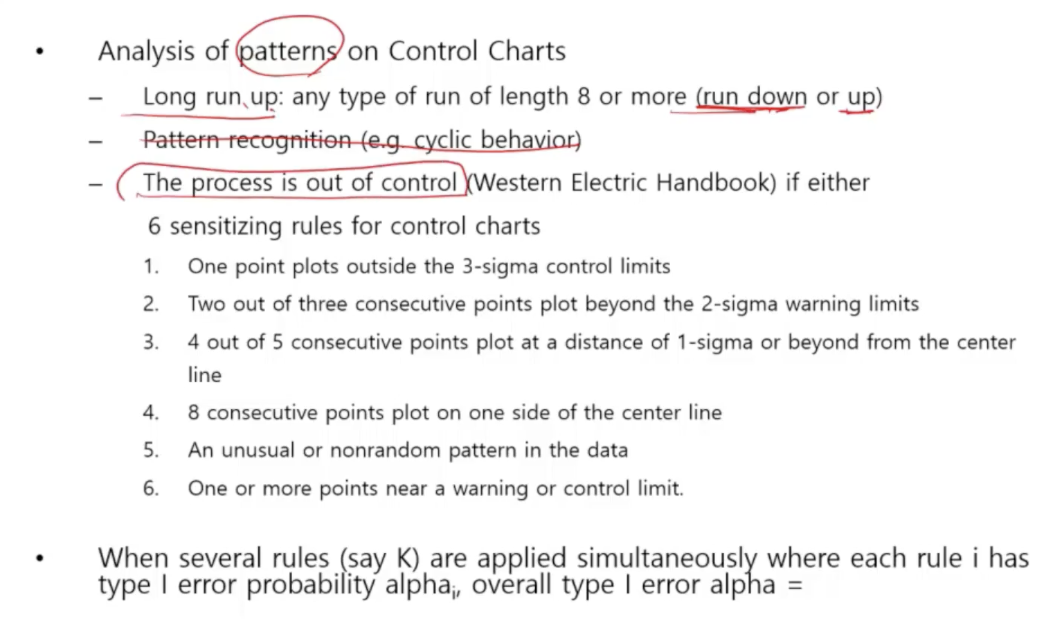

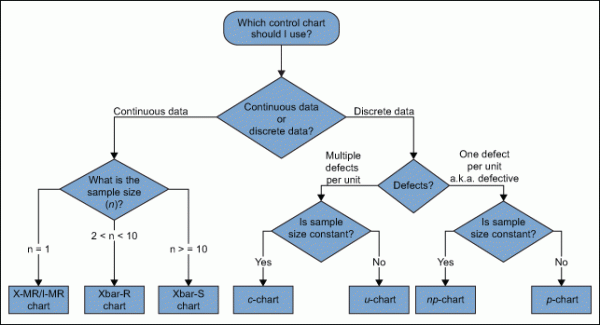

### Variable Control Charts

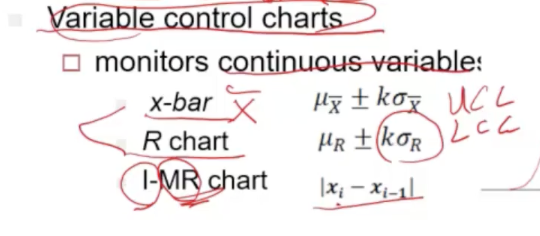

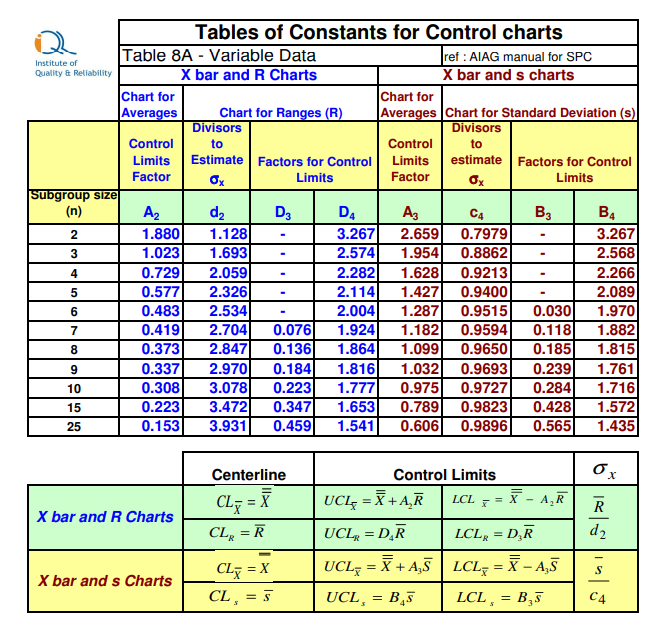
https://web.mit.edu/2.810/www/files/readings/ControlChartConstantsAndFormulae.pdf

1) 현재의 공정이 규격에 맞는 제품을 생산할 능력이 있는가에 대한 판단

2) 새로운 규격의 설정이나 변경에 대한 사항

3) 검사의 기준이나 절차를 새로 정하거나 변경하는데 필요한 정보의 수집

In [ ]:
#manufacturing 철판 두께 데이터
# 20 sets of plate thickness samples of plate thickness samples with a subgroup of size 5

data = np.array([ [57, 46, 62, 23, 19],
                  [52, 49, 42, 60, 32],
                  [64, 53, 33, 20, 32],
                  [46, 61, 55, 24, 44],
                  [26, 47, 21, 62, 48],
                  [36, 64, 63, 42, 38],
                  [22, 52, 44, 49, 43],
                  [56, 38, 56, 44, 46],
                  [52, 33, 40, 30, 65],
                  [57, 55, 30, 35, 46],
                  [53, 24, 63, 49, 43],
                  [24, 33, 38, 67, 24],
                  [65, 36, 32, 48, 35],
                  [38, 61, 48, 43, 38],
                  [68, 42, 21, 29, 43],
                  [60, 48, 44, 19, 60],
                  [43, 28, 32, 65, 22],
                  [57, 47, 69, 56, 24],
                  [31, 29, 48, 63, 42],
                  [39, 68, 20, 51, 26] ])

In [ ]:
sample_size = len(data[0])
number_of_sample = len(data)
print(sample_size,number_of_sample)

5 20


In [ ]:
X = np.zeros((number_of_sample,1)) #평균
R = np.zeros((number_of_sample,1)) #범위
S = np.zeros((number_of_sample,1)) #표준편차
for i in range(number_of_sample):
  X[i] = data[i].mean()
  R[i] = data[i].max() - data[i].min()
  S[i] = data[i].std()
print(X)

[[41.4]
 [47. ]
 [40.4]
 [46. ]
 [40.8]
 [48.6]
 [42. ]
 [48. ]
 [44. ]
 [44.6]
 [46.4]
 [37.2]
 [43.2]
 [45.6]
 [40.6]
 [46.2]
 [38. ]
 [50.6]
 [42.6]
 [40.8]]


##### XR 차트

교재 220, 225 pg  
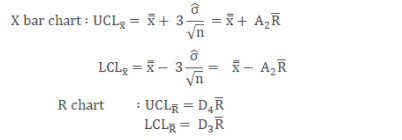

In [ ]:
def XR_ControlChart(data,X,R,A2,D3,D4):
    ucl_X   = X.mean() + A2*R.mean()
    cl_X    = X.mean()
    lcl_X   = X.mean() - A2*R.mean()

    ucl_R   = D4*R.mean()
    cl_R    = R.mean()
    lcl_R   = D3*R.mean()

    #X chart
    plt.figure(figsize=(15,5))
    plt.plot(X,marker="o",color="k",label="X") # data
    plt.plot([ucl_X]*len(X),color="r",label="UCL={}".format(ucl_X.round(2))) #UCL
    plt.plot([cl_X]*len(X),color="b",label="CL={}".format(cl_X.round(2))) #center line
    plt.plot([lcl_X]*len(X),color="r",label="LCL={}".format(lcl_X.round(2))) #LCL
    plt.title("X Chart")
    plt.xticks(np.arange(len(data)))
    plt.legend()
    plt.show()

    #R chart
    plt.figure(figsize=(15,5))
    plt.plot(R,marker="o",color="k",label="R")
    plt.plot([ucl_R]*len(X),color="r",label="UCL={}".format(ucl_R.round(2)))
    plt.plot([cl_R]*len(X),color="b",label="CL={}".format(cl_R.round(2)))
    plt.plot([lcl_R]*len(X),color="r",label="LCL={}".format(lcl_R.round(2)))
    plt.title("R Chart")
    plt.xticks(np.arange(len(data)))
    plt.legend()
    plt.show()

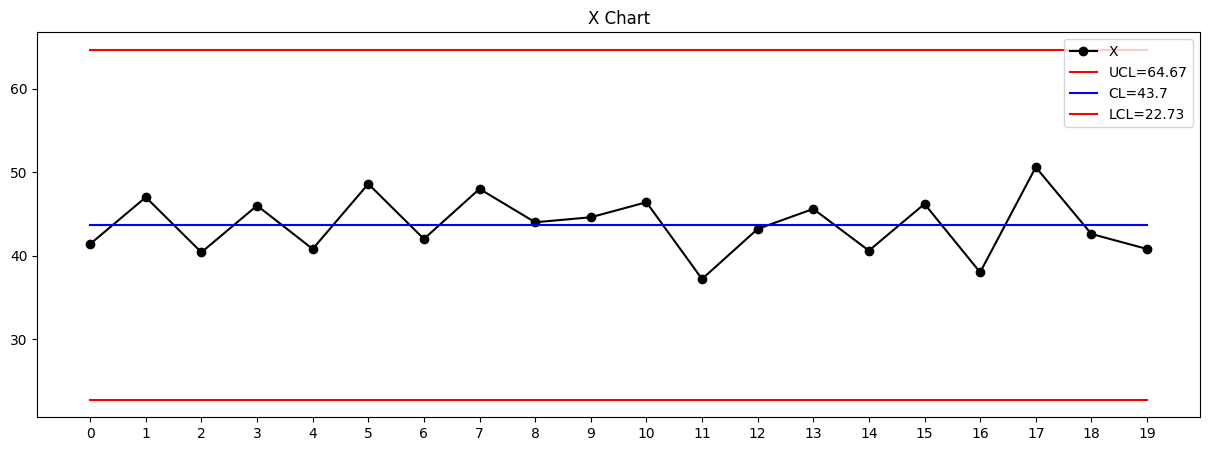

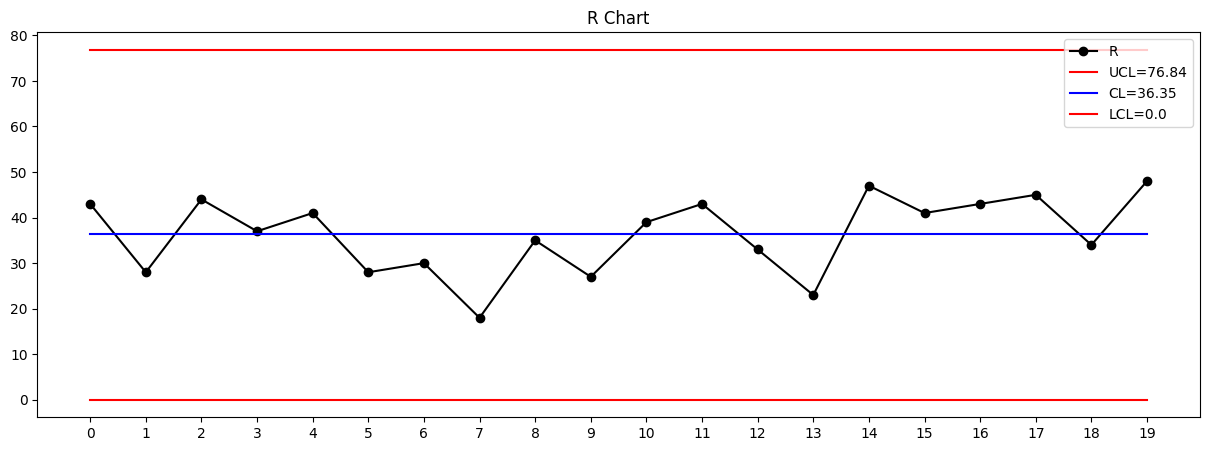

In [ ]:
XR_ControlChart(data,X,R,0.577,0,2.114)

##### XS 차트

교재 220, 233 pg  
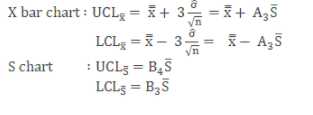

In [ ]:
def XS_ControlChart(data,X,S,A3,B3,B4):
    ucl_X   = X.mean() + A3*S.mean()
    cl_X    = X.mean()
    lcl_X   = X.mean() - A3*S.mean()

    ucl_S   = B4*S.mean()
    cl_S    = S.mean()
    lcl_S   = B3*S.mean()

    #X 그래프
    plt.figure(figsize=(15,5))
    plt.plot(X,marker="o",color="k",label="X")
    plt.plot([ucl_X]*len(X),color="r",label="UCL={}".format(ucl_X.round(2)))
    plt.plot([cl_X]*len(X),color="b",label="CL={}".format(cl_X.round(2)))
    plt.plot([lcl_X]*len(X),color="r",label="LCL={}".format(lcl_X.round(2)))
    plt.title("X Chart")
    plt.xticks(np.arange(len(data)))
    plt.legend()
    plt.show()

    #S 그래프
    plt.figure(figsize=(15,5))
    plt.plot(S,marker="o",color="k",label="S")
    plt.plot([ucl_S]*len(X),color="r",label="UCL={}".format(ucl_S.round(2)))
    plt.plot([cl_S]*len(X),color="b",label="CL={}".format(cl_S.round(2)))
    plt.plot([lcl_S]*len(X),color="r",label="LCL={}".format(lcl_S.round(2)))
    plt.title("S Chart")
    plt.xticks(np.arange(len(data)))
    plt.legend()
    plt.show()


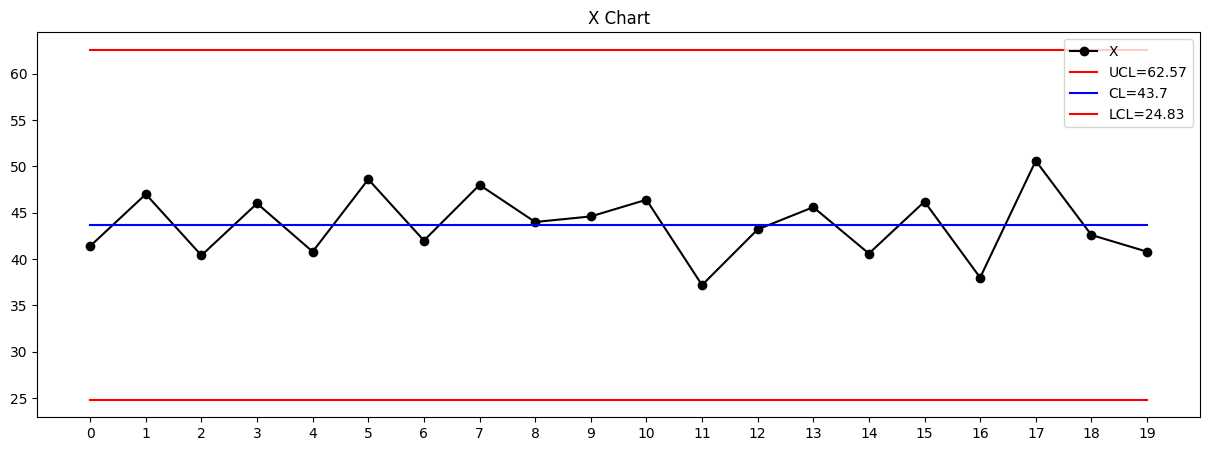

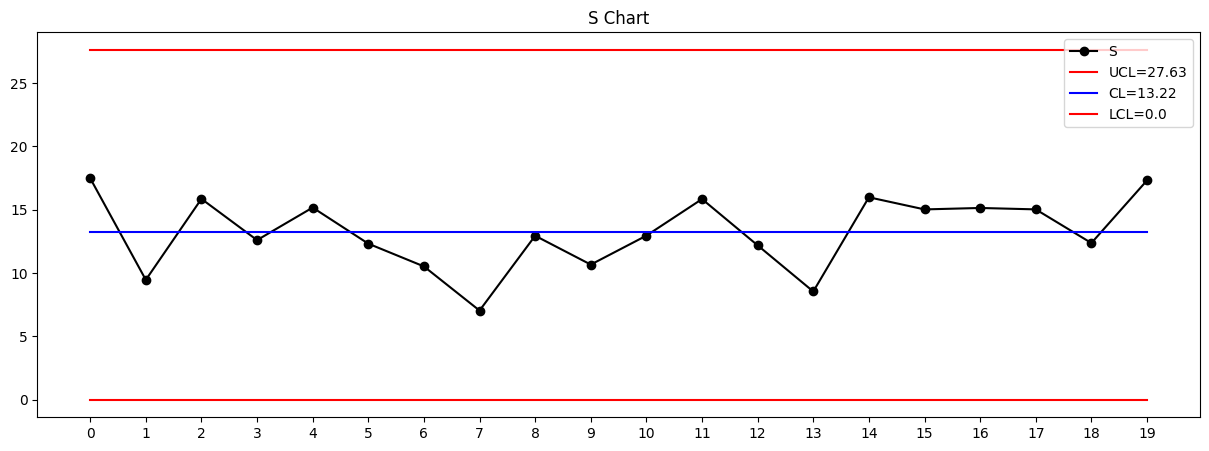

In [ ]:
XS_ControlChart(data,X,S,1.427,0,2.089)

#### I-MR Chart
- small production volume
- high measurement cost
- long unit production cycle
--> difficult to gather subgroup data

I-Chart (Individual)


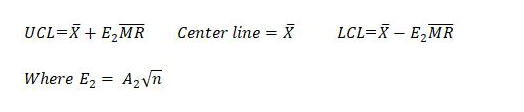

MR-chart (Moving Range)

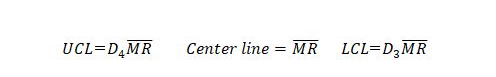

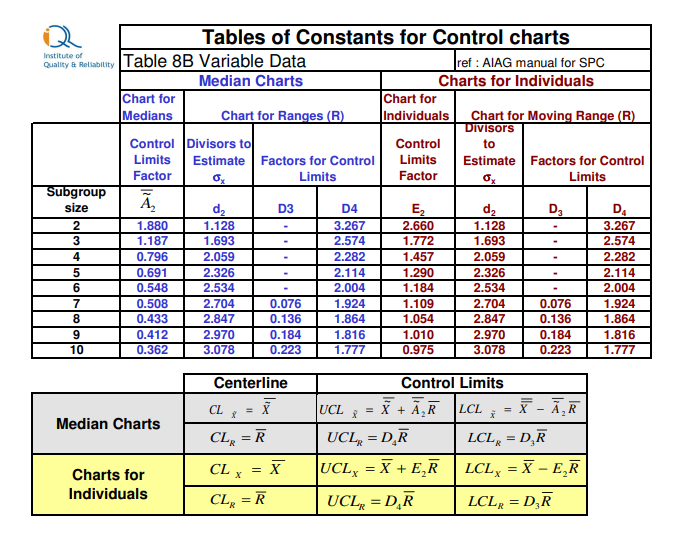

For the I-MR chart, n is always equal to 2 (because we are calculating the moving average of two consecutive points, in other words, it is basically comparing the current state with the previous state).

In [ ]:
# subgroup of size 1
data1=[82,84,75,79,84,81,81,82,80,78,74]

In [ ]:
X=data1
number_of_sample=len(X)
mR=np.zeros((number_of_sample-1,1))
for i in range(len(mR)):
  mR[i]=abs(X[i+1]-X[i])

In [ ]:
def MR_ControlChart(X,mR, A2,D3,D4):
    mR_mean=np.mean(mR)
    X_mean=np.mean(X)

    ucl_X   = X_mean + (3/A2*np.sqrt(2))*mR_mean
    cl_X    = X_mean
    lcl_X   = X_mean - (3/A2*np.sqrt(2))*mR_mean

    ucl_mR   = D4*mR_mean
    cl_mR    = mR_mean
    lcl_mR   = D3*mR_mean


    #I chart
    plt.figure(figsize=(15,5))
    plt.plot(X,marker="o",color="k",label="X")
    plt.plot([ucl_X]*len(X),color="r",label="UCL={}".format(ucl_X.round(2)))
    plt.plot([cl_X]*len(X),color="b",label="CL={}".format(cl_X.round(2)))
    plt.plot([lcl_X]*len(X),color="r",label="LCL={}".format(lcl_X.round(2)))
    plt.title("I Chart")
    plt.xticks(np.arange(len(X)))
    plt.legend()
    plt.show()

    # MR chart
    plt.figure(figsize=(15,5))
    plt.plot(mR ,marker="o",color="k",label="mR ")
    plt.plot([ucl_mR ]*len(X),color="r",label="UCL={}".format(ucl_mR.round(2)))
    plt.plot([cl_mR ]*len(X),color="b",label="CL={}".format(cl_mR.round(2)))
    plt.plot([lcl_mR ]*len(X),color="r",label="LCL={}".format(lcl_mR.round(2)))
    plt.title("mR  Chart")
    plt.xticks(np.arange(len(X)))
    plt.legend()
    plt.show()

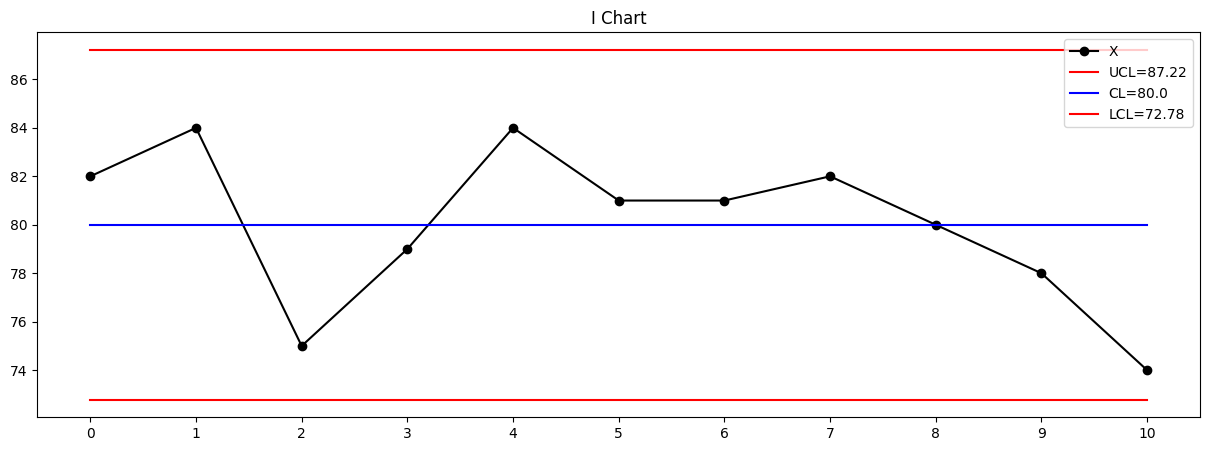

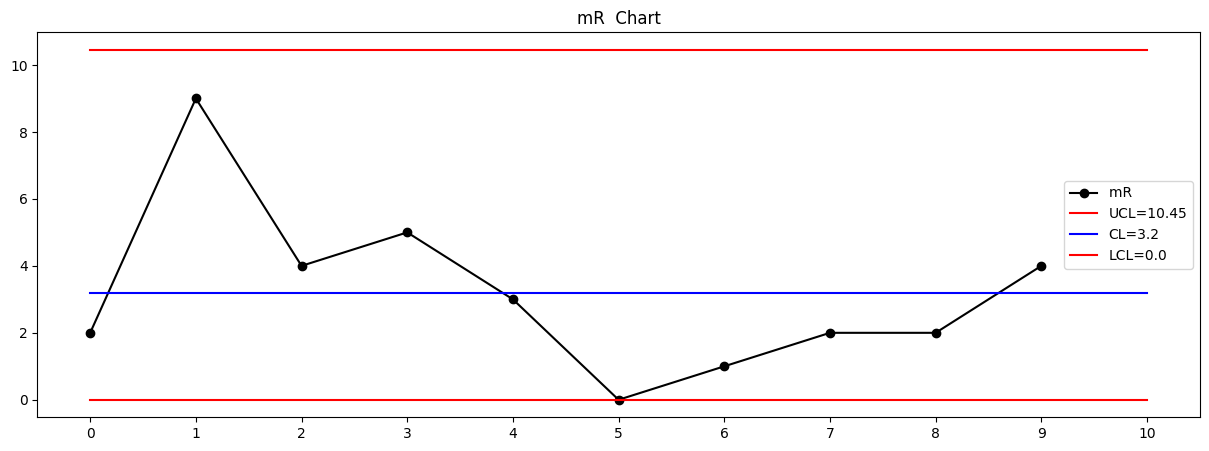

In [ ]:
MR_ControlChart(X, mR, 1.88, 0, 3.267)

### Attribute Control  Charts

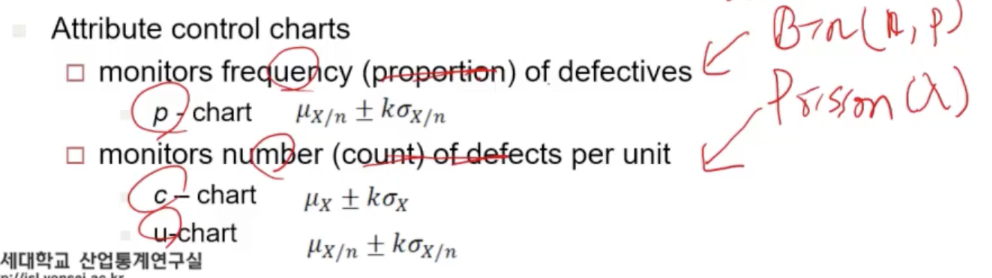

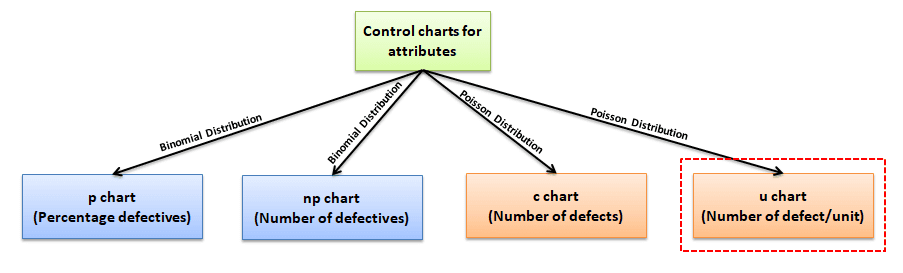

#### P-chart
monitors frequency (proportion) of defectives

전체품목의 표본에서 부적합 부품수의 비율: 부적합품률(p)  
P-chart는 계수치 관리도에서 가장 많이 활용

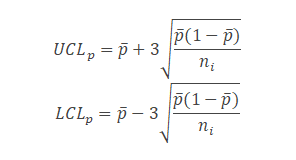

In [ ]:
Defect = [12,15,8,10,4,7,16,9,14,10,5,6,17,12,22,8,10,5,13,11]
sample = [125,130,135,120,105,105,120,110,100,60,135,125,120,110,105,95,156,115,123,110]

In [ ]:
p=np.zeros(len(Defect))
for i in range(len(Defect)):
  p[i]=Defect[i]/sample[i]

In [ ]:
def p_ControlChart(D,size,p):

    p_mean=np.sum(D)/np.sum(size)

    ucl = p_mean + 3*np.sqrt((p_mean*(1-p_mean))/(size)) ## 3 sigma 내의 관리.
    cl  = p_mean
    lcl = p_mean - 3*np.sqrt((p_mean*(1-p_mean))/(size))

    #p 차트
    plt.figure(figsize=(15,5))
    plt.plot(p,marker="o",color="k",label="$p_i$")
    plt.plot(ucl,label="UCL",color="r")
    plt.plot([cl]*(len(D)),label="CL",color="k",alpha=0.4)
    plt.plot(lcl,label="LCL",color="b")
    plt.legend(loc="best")
    plt.xticks(np.arange(len(D)))
    plt.title("p Control Chart")
    plt.show()

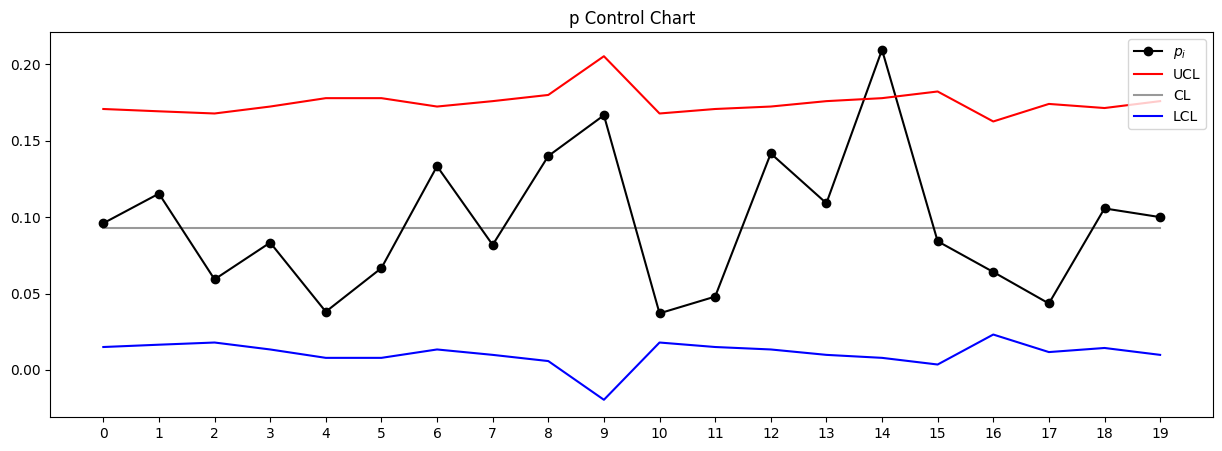

In [ ]:
p_ControlChart(Defect, sample, p)

#### C-Chart

monitors number (count) of defectives per unit ( > 1)

표본의 크기가 동일한 경우 (e.g., 의류 원단을 생산하는 공장에서 생산하는 원단의 크기(면적)이 매일 동일할 때 평균 결점수를 통해 품질 관리)

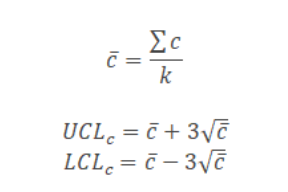

In [2]:
Defect = [12,15,8,10,4,7,16,9,14,10,5,6,17,12,22,8,10,5,13,11]
size = len(Defect)

In [ ]:
def C_ControlChart(Defect,n):
  c_mean=np.sum(Defect)/n

  ucl = c_mean + 3 * np.sqrt(c_mean)
  cl  = c_mean
  lcl = c_mean - 3 * np.sqrt(c_mean)

  plt.figure(figsize=(15,5))
  plt.plot(Defect,marker="o",color="k",label="$C_i$")
  plt.plot([ucl]*len(Defect),color="r",label="UCL{}".format(ucl.round(2)))
  plt.plot([cl]*len(Defect),color="k",alpha=0.4,label="CL{}".format(cl.round(2)))
  plt.plot([lcl]*len(Defect),color="r",label="LCL{}".format(lcl.round(2)))
  plt.xticks(np.arange(len(Defect)))
  plt.legend(loc="best")
  plt.title("c - Control Chart")
  plt.show()


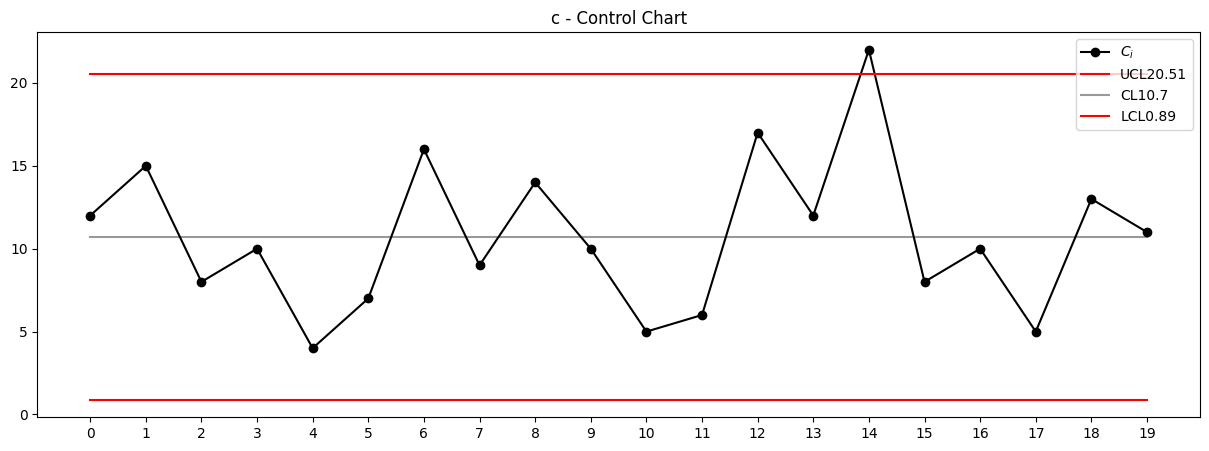

In [ ]:
C_ControlChart(Defect, size)

#### U-Chart

monitors number (count) of defectives per unit ( = 1)

표본의 크기가 동일하지 않은 경우 (e.g., 의류 원단을 생산하는 공장에서 생산하는 원단의 크기(면적)가 매일 달라지며 이에 따라 추출하는 표본의 크기도 매번 달라지는 경우 1㎡당 평균 결점 수를 대상으로 품질 관리)

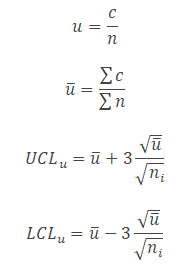

In [ ]:
Defect=[12,15,8,10,4,7,16,9,14,10,5,6,17,12,22,8,10,5,13,11]
size = [125,130,135,120,105,105,120,110,100,60,135,125,120,110,105,95,156,115,123,110]

In [ ]:
def u_ControlChart(Defect,size):

    u_mean=np.sum(Defect)/np.sum(size)
    value=[Defect[i]/size[i] for i in range(len(Defect))]

    ucl = u_mean + 3 * np.sqrt(u_mean/size)
    cl  = u_mean
    lcl = u_mean - 3 * np.sqrt(u_mean/size)

    plt.figure(figsize=(15,5))
    plt.plot(value,marker="o",color="k",label="$C_i$")
    plt.plot(ucl,color="r",label="UCL{}".format(ucl.round(2)))
    plt.plot([cl]*len(size),color="k",alpha=0.4,label="CL{}".format(cl.round(2)))
    plt.plot(lcl,color="r",label="LCL{}".format(lcl.round(2)))
    plt.xticks(np.arange(len(Defect)))
    plt.title("u - Control Chart")
    plt.show()

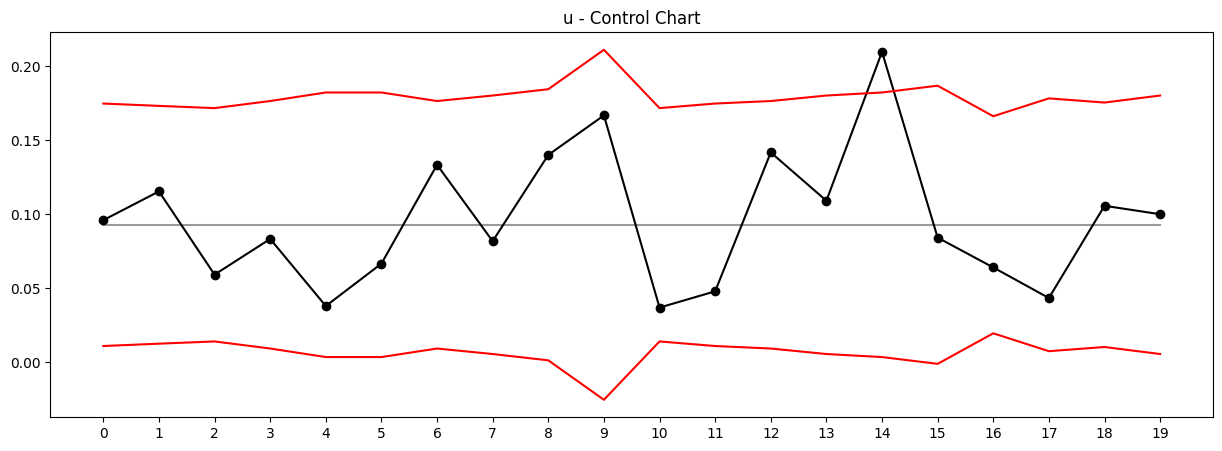

In [ ]:
u_ControlChart(Defect,size)

### Optional) EWMA-chart

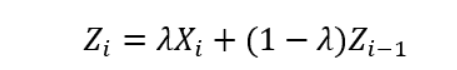

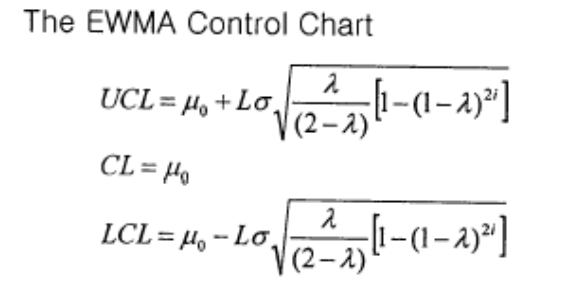

https://www.ncss.com/wp-content/themes/ncss/pdf/Procedures/NCSS/EWMA_Charts.pdf

In [ ]:
data = np.array([ 9.86309233,  9.84000103, 10.97886276,  9.50805567,  9.79770921,
       10.3763538 , 10.77708283, 10.91984387, 10.58749389, 10.55658341,
       10.56227153,  9.23660779, 10.66084511, 10.12406454,  9.22176616,
       10.23525939,  9.63873061, 10.63521265,  9.34684212,  9.74626569,
        9.55167571,  9.203874  ,  9.11321254,  9.28478856, 10.21514137,
       10.93835811,  9.00417726, 10.20495895, 10.12245382,  9.46752498])

In [ ]:
def EWMA_ControlChart(data,L,lamda,mean,sigma):
  z=np.zeros(len(data))
  z[0]=mean
  for i in range(1,len(z)):
    z[i]=lamda*data[i]+(1-lamda)*z[i-1]
  ucl = np.zeros(len(data))
  lcl = np.zeros(len(data))
  I   = np.arange(1,len(data)+1)

  for i in range(len(data)):
      ucl[i] = mean + L*sigma*np.sqrt((lamda / (2 - lamda))*(1-(1-lamda)**(I[i])))
      lcl[i] = mean - L*sigma*np.sqrt((lamda / (2 - lamda))*(1-(1-lamda)**(I[i])))

  plt.figure(figsize=(15,5))
  plt.plot(z,marker="o",color="k",label="$Z_i$")
  plt.plot([mean]*len(data),color="k",alpha=0.35)
  plt.plot(ucl,color="r",label="UCL {}".format(ucl[len(ucl)-1].round(2)))
  plt.plot(lcl,color="r",label="LCL {}".format(lcl[len(lcl)-1].round(2)))
  plt.title("EWMA Conrol Chart")
  plt.legend(loc="upper left")
  plt.show()

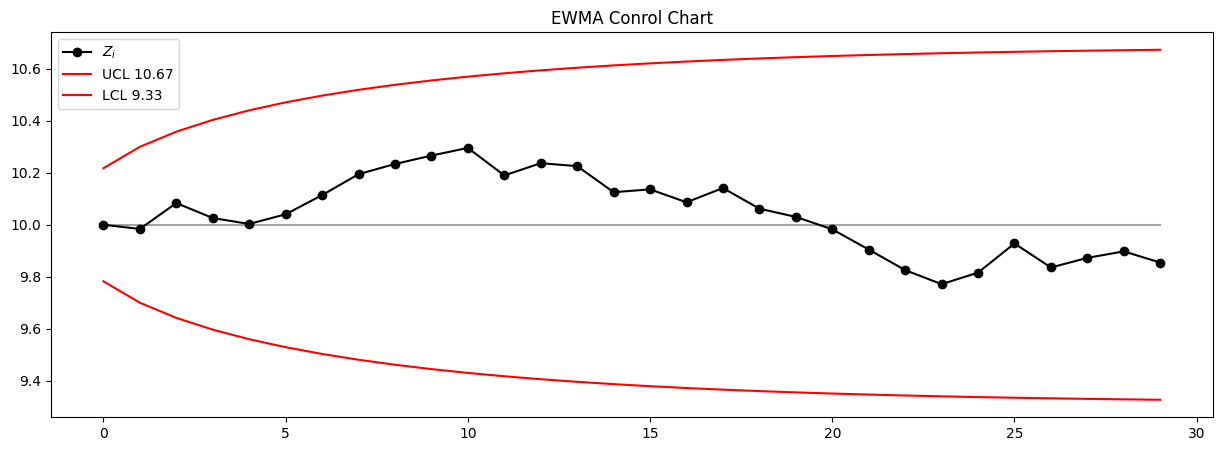

In [ ]:
EWMA_ControlChart(data,3,0.1,np.mean(data),1)

https://www.kaggle.com/nalkrolu/statistical-process-control-quality-control/notebook  
https://github.com/plotly/datasets/blob/master/pareto-chart.csv   
https://rfriend.tistory.com/413  
https://blog.kainexus.com/improvement-disciplines/lean/control-charts/an-introduction-to-process-control-charts  
https://sixsigmastudyguide.com/x-bar-r-control-charts/  
https://web.mit.edu/2.810/www/files/readings/ControlChartConstantsAndFormulae.pdf  
https://sixsigmastudyguide.com/x-bar-s-chart/  
https://sixsigmastudyguide.com/i-mr-chart/  
https://sixsigmastudyguide.com/p-attribute-charts/  
https://sixsigmastudyguide.com/attribute-chart-c-chart/  
https://sixsigmastudyguide.com/attribute-chart-u-chart/  

### 실습 예시

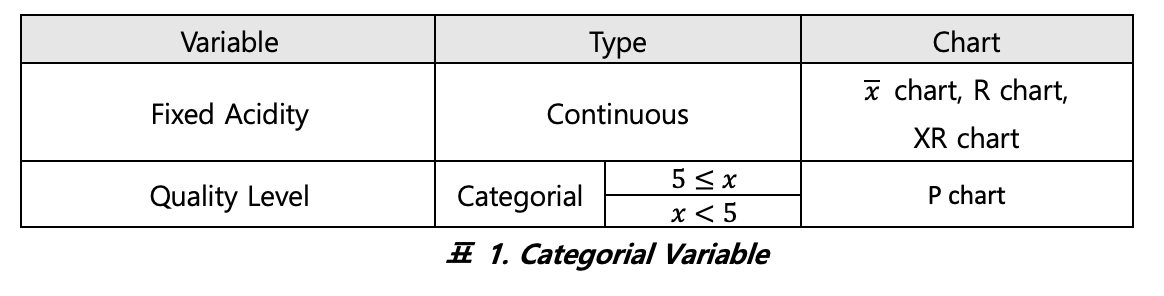

* used famous "wine quality data"

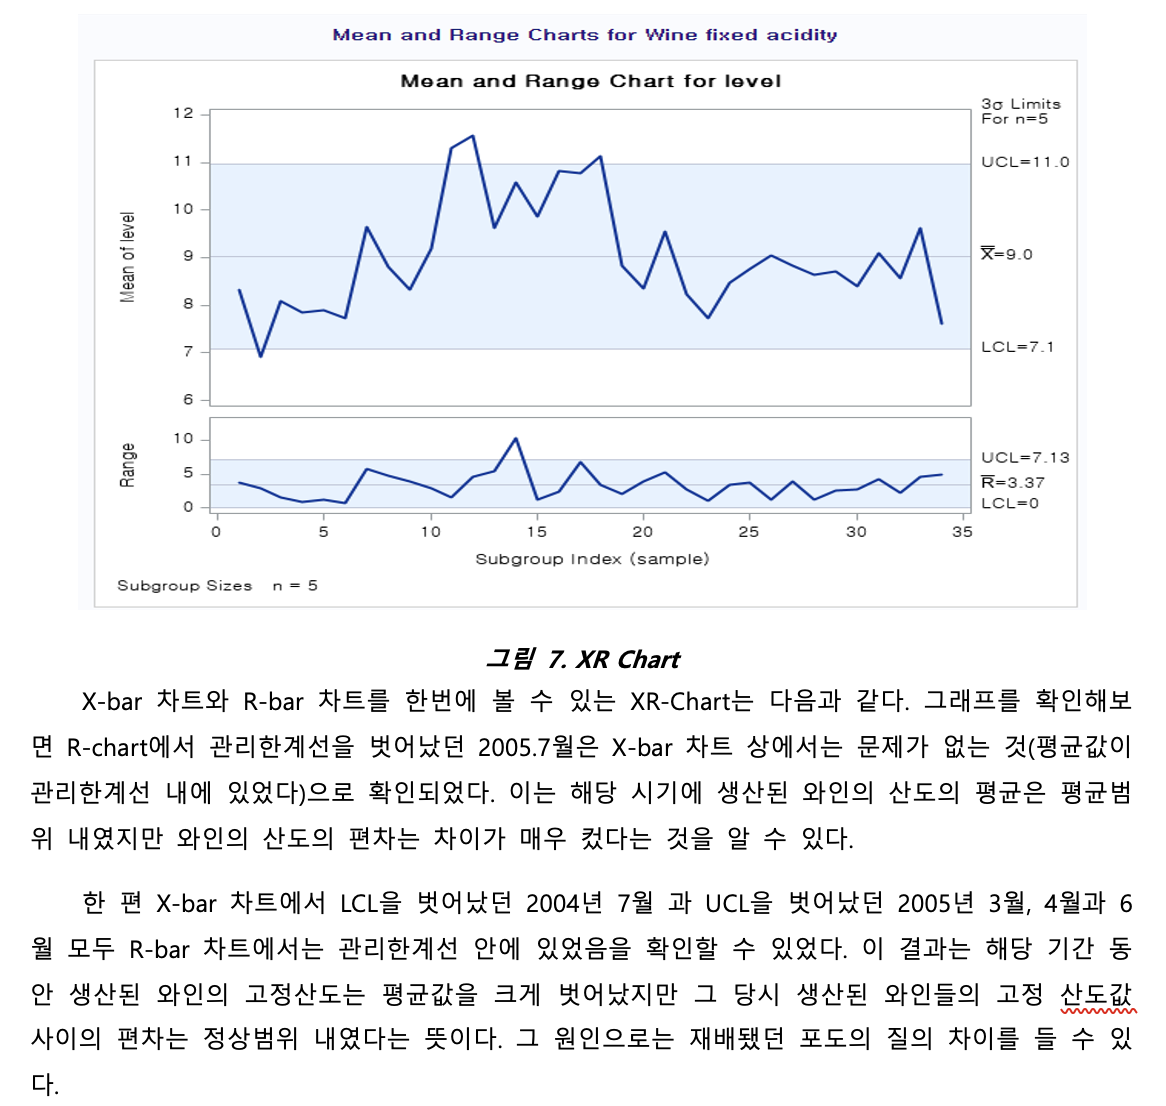

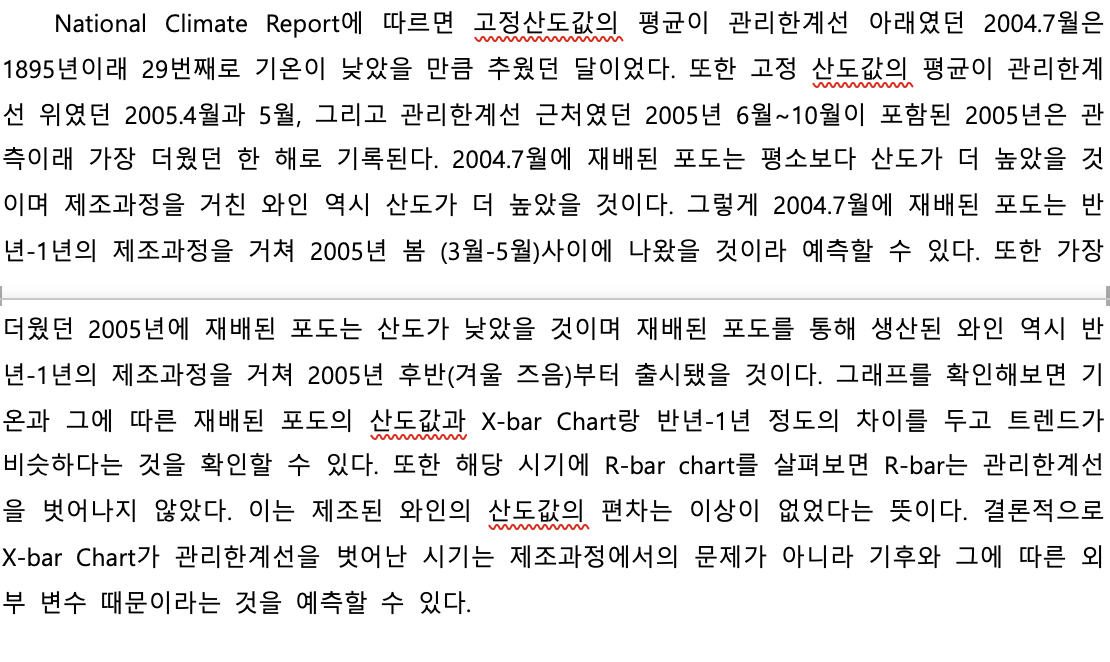

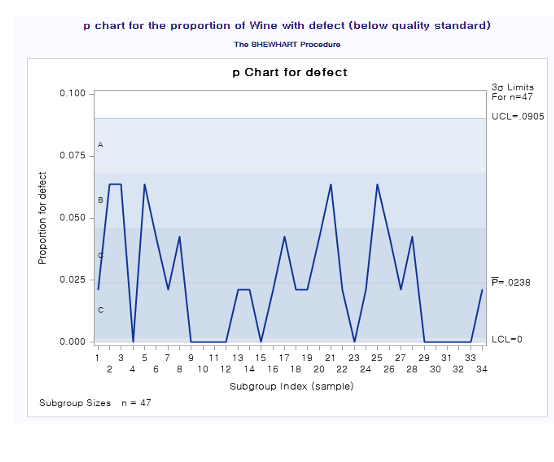

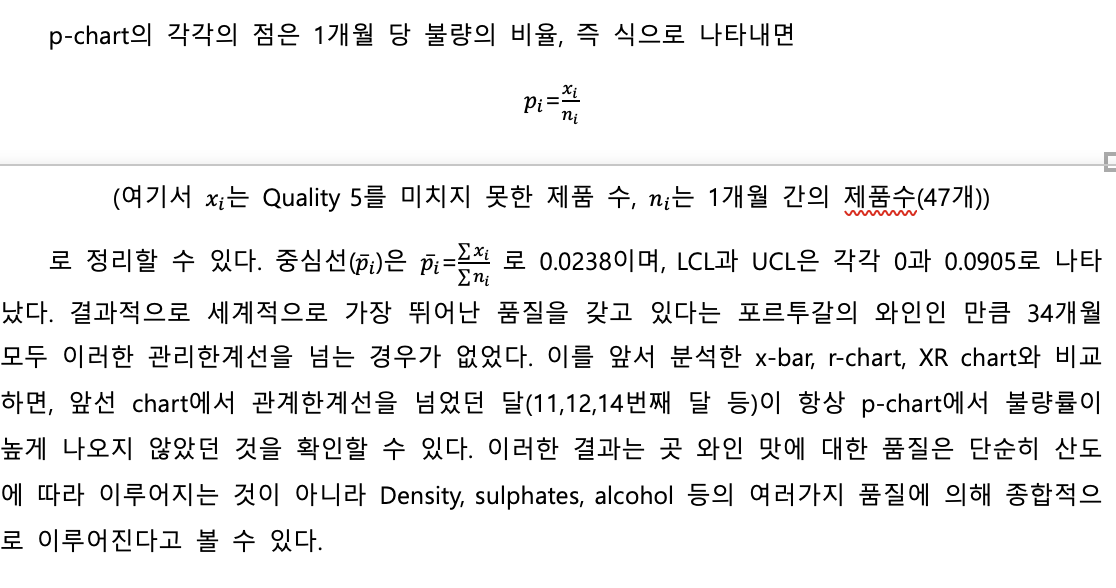